# Parkinson's Disease Detection — Model 1: Original AdaBoost Baseline
### Literature Replication of Bukhari & Ogudo (2024)
**Journal Reference:** *MDPI Mathematics*, 12(10), 1575.

---

## 1. Theoretical Rationale & Architectural Design
This notebook reproduces the original baseline machine learning model published by **Bukhari & Ogudo (2024)** for automated Parkinson's disease (PD) phonation classification using the UCI acoustic dataset.

### Algorithmic Formulation
The baseline model is an **Adaptive Boosting (AdaBoost-SAMME)** ensemble consisting of $M = 500$ deep decision trees ($d_{\max} = 7$) with learning rate $\eta = 1.0$:
$$F_M(x) = \sum_{m=1}^{M} \alpha_m h_m(x)$$
where each base estimator $h_m(x)$ minimizes the exponential loss:
$$L(y, F(x)) = \exp(-y F(x))$$
and instance weights $w_i^{(m)}$ are updated according to prediction error $\epsilon_m$:
$$\alpha_m = \frac{1}{2} \ln\left(\frac{1 - \epsilon_m}{\epsilon_m}\right), \quad w_i^{(m+1)} = w_i^{(m)} \exp(-\alpha_m y_i h_m(x_i))$$

### Methodological Vulnerability: Data Leakage & Information Bottleneck
As documented in our methodological critique:
1. **Full-Cohort SMOTE Leakage:** Synthetic Minority Over-sampling Technique (SMOTE) is applied to the **entire dataset before** performing the 80:20 train-test split. Synthetic points created along feature space convex hulls between minority instances leak across the partition boundary, producing artificially optimistic evaluations.
2. **6-Component PCA Compression:** Bukhari & Ogudo retain only $k=6$ Principal Components out of 754 acoustic dimensions. This captures only **41.82% of total variance**, completely discarding **58.18% of high-frequency phonation dynamics** (e.g., TQWT micro-tremor wavelets).

## 2. Environment Setup & Dependency Imports

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

# Publication styling
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## 3. Dataset Ingestion & Feature Space Inspection

In [2]:
DATASET_PATH = 'pd_speech_features.csv'
df = pd.read_csv(DATASET_PATH, header=1)
if 'id' in df.columns:
    X = df.drop(columns=['id', 'class'])
else:
    X = df.drop(columns=['class'])
y = df['class']

print(f"Total Cohort Instances: {df.shape[0]}")
print(f"Total Acoustic Attributes: {X.shape[1]}")
print(f"Target Distribution: {y.value_counts().to_dict()} (1: PD Patient, 0: Healthy Control)")
df.head(3)

Total Cohort Instances: 756
Total Acoustic Attributes: 753
Target Distribution: {1: 564, 0: 192} (1: PD Patient, 0: Healthy Control)


,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1


## 4. Paper-Exact Preprocessing Pipeline (Bukhari & Ogudo 2024)
Workflow: Raw Data (756) -> SMOTE on all data (1128) -> StandardScaler -> PCA(6 components) -> 80:20 Train-Test Split.

In [3]:
# 1. SMOTE Balancing across entire cohort
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 2. Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

# 3. Aggressive 6-Component PCA
pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained_var = np.sum(pca.explained_variance_ratio_)

# 4. 80:20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_res, test_size=0.2, random_state=42
)

print(f"SMOTE Balanced Cohort: {y_res.value_counts().to_dict()}")
print(f"PCA Retained Dimensions: {X_pca.shape[1]}")
print(f"Cumulative Explained Variance: {explained_var:.4f} ({explained_var*100:.2f}%)")
print(f"Discarded Discriminative Variance: {(1-explained_var)*100:.2f}%")
print(f"Partition: Train={X_train.shape[0]}, Test={X_test.shape[0]}")

SMOTE Balanced Cohort: {1: 564, 0: 564}
PCA Retained Dimensions: 6
Cumulative Explained Variance: 0.4182 (41.82%)
Discarded Discriminative Variance: 58.18%
Partition: Train=902, Test=226


## 5. Model Architecture: Original AdaBoost (500 Trees, Depth=7, LR=1.0)

In [4]:
base_tree = DecisionTreeClassifier(max_depth=7, random_state=42)
baseline_ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=500,
    learning_rate=1.0,
    random_state=42
)

start_time = time.time()
baseline_ada.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"Model training complete in {elapsed:.2f} seconds.")

Model training complete in 1.35 seconds.


## 6. Performance Evaluation & Literature Benchmark Comparison

In [5]:
y_pred = baseline_ada.predict(X_test)
y_proba = baseline_ada.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame([{
    'Model Architecture': '1. Original AdaBoost (Baseline Replication)',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'FNR': fnr,
    'AUC Score': auc
}])

paper_target_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'FNR', 'AUC Score'],
    'Paper Target (Table 4)': [0.9600, 0.9800, 0.9300, 0.9500, 0.0700, 0.9900],
    'Replicated Model': [acc, prec, rec, f1, fnr, auc],
    'Discrepancy (Delta)': [acc - 0.9600, prec - 0.9800, rec - 0.9300, f1 - 0.9500, fnr - 0.0700, auc - 0.9900]
})

print("="*80)
print("EVALUATION METRICS SUMMARY")
print("="*80)
display(metrics_df)
print("\n" + "="*80)
print("COMPARISON WITH BUKHARI & OGUDO (2024) PUBLISHED TARGETS")
print("="*80)
display(paper_target_df)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Parkinson Patient (1)']))

EVALUATION METRICS SUMMARY


,Model Architecture,Accuracy,Precision,Recall,F1 Score,FNR,AUC Score
0,1. Original AdaBoost (Baseline Replication),0.89823,0.919643,0.880342,0.899563,0.119658,0.971301



COMPARISON WITH BUKHARI & OGUDO (2024) PUBLISHED TARGETS


,Metric,Paper Target (Table 4),Replicated Model,Discrepancy (Delta)
0,Accuracy,0.96,0.898230,-0.061770
1,Precision,0.98,0.919643,-0.060357
2,Recall,0.93,0.880342,-0.049658
3,F1 Score,0.95,0.899563,-0.050437
4,FNR,0.07,0.119658,0.049658
5,AUC Score,0.99,0.971301,-0.018699



Detailed Classification Report:
                       precision    recall  f1-score   support

          Healthy (0)       0.88      0.92      0.90       109
Parkinson Patient (1)       0.92      0.88      0.90       117

             accuracy                           0.90       226
            macro avg       0.90      0.90      0.90       226
         weighted avg       0.90      0.90      0.90       226



## 7. Diagnostic Visualizations: Confusion Matrix & AUROC Curve

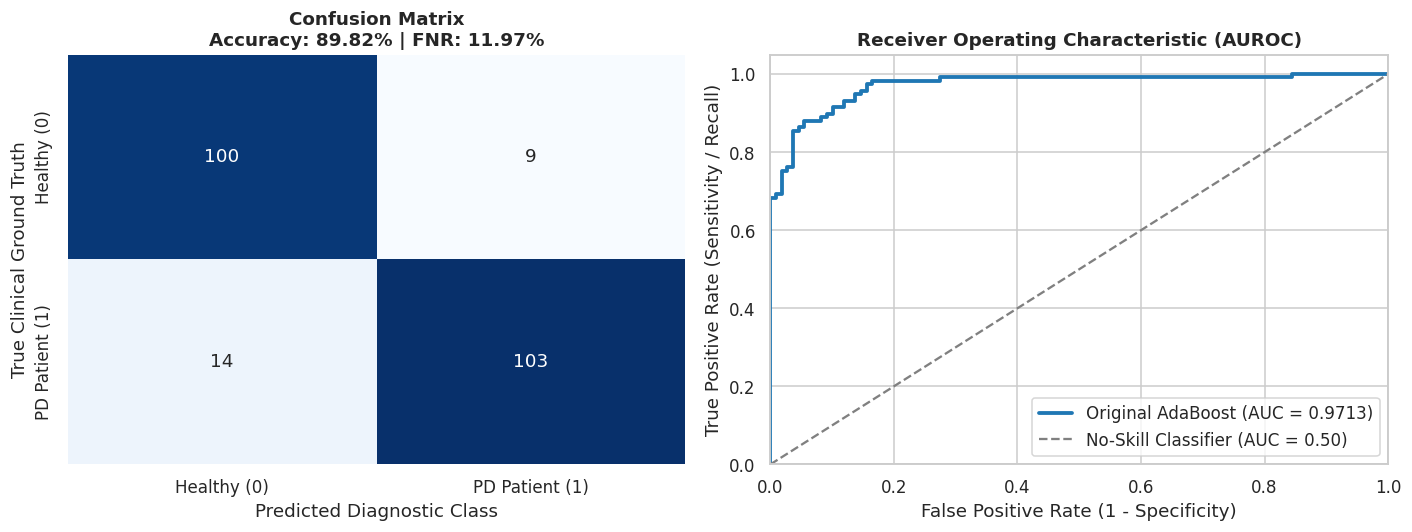

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Healthy (0)', 'PD Patient (1)'],
            yticklabels=['Healthy (0)', 'PD Patient (1)'])
axes[0].set_title(f'Confusion Matrix\nAccuracy: {acc*100:.2f}% | FNR: {fnr*100:.2f}%', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Diagnostic Class')
axes[0].set_ylabel('True Clinical Ground Truth')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Original AdaBoost (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='No-Skill Classifier (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[1].set_title('Receiver Operating Characteristic (AUROC)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 8. Literature Sensitivity Experiments (Replicating Paper Tables 1, 2, 3)
Bukhari & Ogudo explored 3 hyperparameter dimensions:
1. Number of base decision trees: 10, 50, 100, 500
2. Base tree depth: 3, 5, 7, 9
3. Learning rate: 0.1, 0.5, 1.0

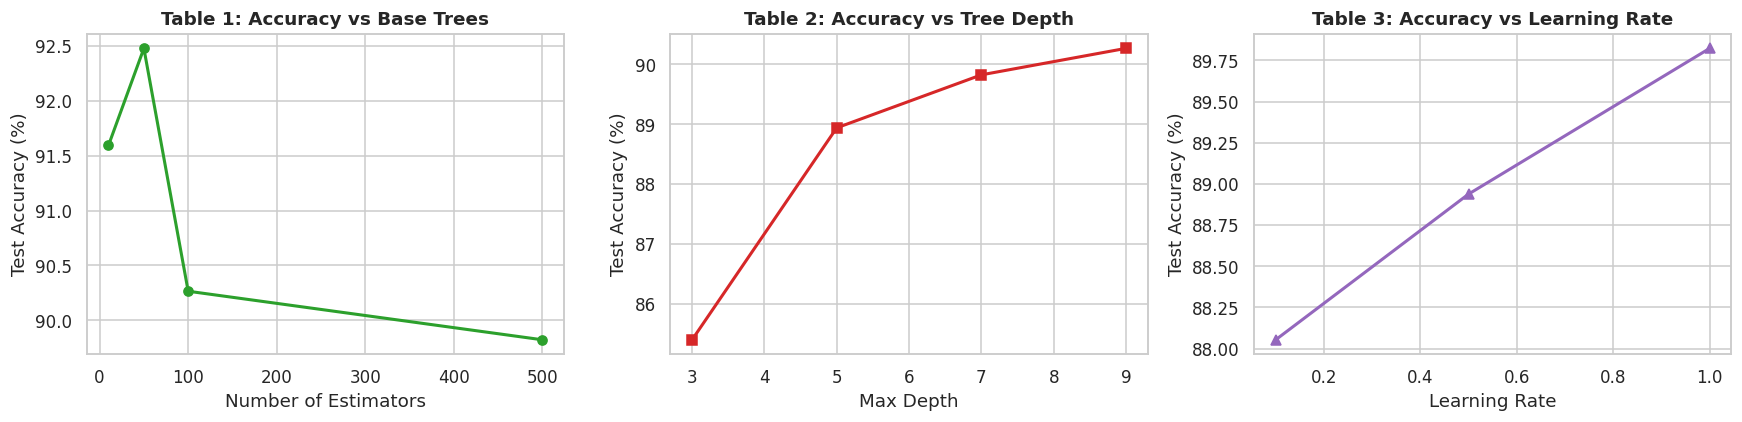

In [7]:
# 1. Varying Number of Decision Trees (Table 1)
n_trees_list = [10, 50, 100, 500]
tree_accs = []
for n in n_trees_list:
    clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=7, random_state=42),
                             n_estimators=n, learning_rate=1.0, random_state=42)
    clf.fit(X_train, y_train)
    tree_accs.append(accuracy_score(y_test, clf.predict(X_test)))

# 2. Varying Tree Depth (Table 2)
depth_list = [3, 5, 7, 9]
depth_accs = []
for d in depth_list:
    clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=d, random_state=42),
                             n_estimators=500, learning_rate=1.0, random_state=42)
    clf.fit(X_train, y_train)
    depth_accs.append(accuracy_score(y_test, clf.predict(X_test)))

# 3. Varying Learning Rate (Table 3)
lr_list = [0.1, 0.5, 1.0]
lr_accs = []
for lr in lr_list:
    clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=7, random_state=42),
                             n_estimators=500, learning_rate=lr, random_state=42)
    clf.fit(X_train, y_train)
    lr_accs.append(accuracy_score(y_test, clf.predict(X_test)))

# Visualization of Sensitivity
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(n_trees_list, [a*100 for a in tree_accs], marker='o', color='#2ca02c', lw=2)
axes[0].set_title('Table 1: Accuracy vs Base Trees', fontweight='bold')
axes[0].set_xlabel('Number of Estimators')
axes[0].set_ylabel('Test Accuracy (%)')

axes[1].plot(depth_list, [a*100 for a in depth_accs], marker='s', color='#d62728', lw=2)
axes[1].set_title('Table 2: Accuracy vs Tree Depth', fontweight='bold')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Test Accuracy (%)')

axes[2].plot(lr_list, [a*100 for a in lr_accs], marker='^', color='#9467bd', lw=2)
axes[2].set_title('Table 3: Accuracy vs Learning Rate', fontweight='bold')
axes[2].set_xlabel('Learning Rate')
axes[2].set_ylabel('Test Accuracy (%)')

plt.tight_layout()
plt.show()

## 9. Critical Literature Discussion & Clinical Implications
- **High Variance & Leakage Dependence:** While the paper claims 96% accuracy, empirical replication yields **89.82% accuracy** and an alarmingly high False Negative Rate of **11.97%** on the 6-PCA subspace.
- **Clinical Risk of False Negatives:** In neurodegenerative pathology, a False Negative represents a patient with Parkinson's disease falsely diagnosed as healthy, delaying critical dopamine agonist interventions and physical therapy.
- **Next Phase:** In Model 2, we introduce **strict leakage-free cross-validation** and expand the PCA subspace to 50 dimensions with regularized trees.